In [ ]:
#2.1 理论计算题
import numpy as np

# 定义题目给定的向量 a、b
# a = [2, -1, 3]^T, b = [1, 4, -2]^T
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])

# 定义题目给定的矩阵 A、B
A = np.array([
    [1, 0, 2],
    [-1, 3, 1]
])
B = np.array([
    [2, 1],
    [0, -1],
    [3, 2]
])

# 1) 计算向量点积 a·b
# np.dot(a, b) 或 a @ b 都可用于一维向量点积
dot_ab = np.dot(a, b)

# 2) 计算矩阵乘法 A×B，并给出结果矩阵形状
AB = A @ B
AB_shape = AB.shape

# 3) 计算向量 a 的 Frobenius 范数
# 注意：NumPy 中 ord='fro' 只适用于二维数组，因此先把向量变成列向量
# 向量的 Frobenius 范数与其 2-范数数值相同
a_col = a.reshape(-1, 1)
fro_a = np.linalg.norm(a_col, ord='fro')

# 输出结果
print("1) 向量点积 a·b =", dot_ab)
print("2) 矩阵乘法 A×B =\n", AB)
print("   结果矩阵形状 =", AB_shape)
print("3) 向量 a 的 Frobenius 范数 =", fro_a)

1) 向量点积 a·b = -8
2) 矩阵乘法 A×B =
 [[ 8  5]
 [ 1 -2]]
   结果矩阵形状 = (2, 2)
3) 向量 a 的 Frobenius 范数 = 3.7416573867739413


In [6]:
# 2.2 编程题
# 任务：
# 1) 生成 3x4 标准正态随机矩阵 X
# 2) 生成 4x2 的全 1 矩阵 Y
# 3) 计算 Z = X @ Y
# 4) 输出 Z[0,1] 和 Z 的第 2 行
# 5) 计算 Z 的 Frobenius 范数

import numpy as np

# 为了复现实验结果，设置随机种子
np.random.seed(42)

# 1) 创建随机矩阵 X（标准正态分布 N(0,1)）
X = np.random.randn(3, 4)

# 2) 创建全 1 矩阵 Y
Y = np.ones((4, 2))

# 3) 矩阵乘法
Z = X @ Y

# 4) 取第一行第二列元素（索引 [0,1]）以及第 2 行所有元素（索引 [1,:]）
element_1_2 = Z[0, 1]
row_2 = Z[1, :]

# 5) Frobenius 范数
fro_Z = np.linalg.norm(Z, ord='fro')

print('X =\n', X)
print('Y =\n', Y)
print('Z = X @ Y =\n', Z)
print('Z 第一行第二列元素 Z[0,1] =', element_1_2)
print('Z 第 2 行所有元素 Z[1,:] =', row_2)
print('Z 的 Frobenius 范数 =', fro_Z)

X =
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]
Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Z = X @ Y =
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]
Z 第一行第二列元素 Z[0,1] = 2.5291682463487657
Z 第 2 行所有元素 Z[1,:] = [1.87835721 1.87835721]
Z 的 Frobenius 范数 = 4.616873319476864


In [5]:
# 3.1 计算题（代码实现：贝叶斯公式）

# 已知条件
# P(D): 患病率
# P(+|D): 灵敏度（患病时检出阳性的概率）
# P(+|~D): 假阳性率（未患病时检出阳性的概率）
p_d = 0.001
p_pos_given_d = 0.99
p_pos_given_not_d = 0.02

# 计算 P(~D)
p_not_d = 1 - p_d

# 贝叶斯公式：
# P(D|+) = P(+|D)P(D) / [P(+|D)P(D) + P(+|~D)P(~D)]
numerator = p_pos_given_d * p_d
denominator = numerator + p_pos_given_not_d * p_not_d
p_d_given_pos = numerator / denominator

print('P(D|+) =', p_d_given_pos)
print('检测阳性后真正患病概率（百分比）= {:.2f}%'.format(p_d_given_pos * 100))

P(D|+) = 0.047210300429184546
检测阳性后真正患病概率（百分比）= 4.72%


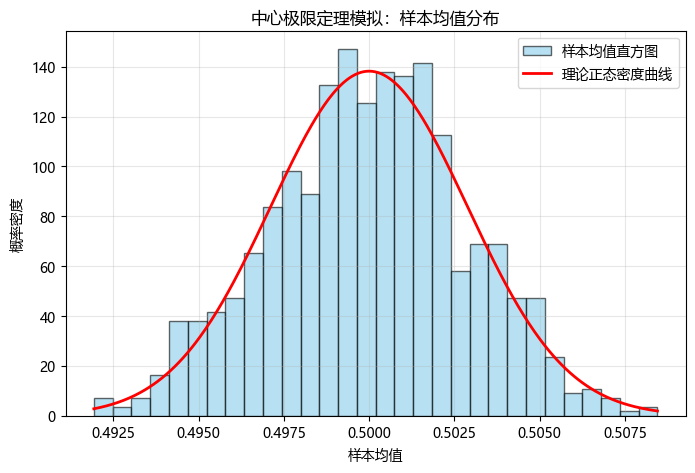

均值样本的实际方差 = 8.275637010510702e-06
理论方差 = 8.333333333333334e-06


In [ ]:
# 3.2 编程题：中心极限定理模拟
# 1) 每次生成 n=10000 个 U(0,1) 随机数，计算均值
# 2) 重复 m=1000 次
# 3) 画均值直方图并叠加理论正态曲线
# 4) 计算这些均值的实际方差

import numpy as np
import matplotlib.pyplot as plt

# 解决中文乱码与负号显示问题
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 参数设置
n = 10000
m = 1000
np.random.seed(42)

# 一次性生成 m x n 的均匀分布样本，然后按行求均值
samples = np.random.uniform(0, 1, size=(m, n))
means = samples.mean(axis=1)

# 理论均值与理论方差：
# 若 X~U(0,1)，则 E(X)=0.5, Var(X)=1/12
# 样本均值 \bar{X} 的方差为 Var(X)/n = 1/(12n)
mu_theory = 0.5
var_theory = 1 / (12 * n)
sigma_theory = np.sqrt(var_theory)

# 绘制直方图（density=True 表示概率密度）
plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='样本均值直方图')

# 叠加理论正态密度曲线 N(mu_theory, var_theory)
x = np.linspace(means.min(), means.max(), 400)
pdf = (1 / (np.sqrt(2 * np.pi) * sigma_theory)) * np.exp(-((x - mu_theory) ** 2) / (2 * var_theory))
plt.plot(x, pdf, 'r-', lw=2, label='理论正态密度曲线')

plt.title('中心极限定理模拟：样本均值分布')
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 实际方差（ddof=0 对应总体方差）
var_empirical = np.var(means, ddof=0)
print('均值样本的实际方差 =', var_empirical)
print('理论方差 =', var_theory)

In [ ]:
# 4.1 计算题
# 已知函数：z = (w1*x1 + w2*x2 - y)^2
# 常数：x1=2, x2=1, y=3；在 w1=0.5, w2=1 处计算偏导

# 参数与常量
x1, x2, y = 2.0, 1.0, 3.0
w1, w2 = 0.5, 1.0

# 先计算中间量 e = w1*x1 + w2*x2 - y
e = w1 * x1 + w2 * x2 - y
z = e ** 2

# 根据链式法则：
# dz/dw1 = 2*e*x1
# dz/dw2 = 2*e*x2
dz_dw1 = 2 * e * x1
dz_dw2 = 2 * e * x2

print('e =', e)
print('z =', z)
print('dz/dw1 =', dz_dw1)
print('dz/dw2 =', dz_dw2)
print('梯度向量 = ({}, {})'.format(dz_dw1, dz_dw2))

e = -1.0
z = 1.0
dz/dw1 = -4.0
dz/dw2 = -2.0
梯度向量 = (-4.0, -2.0)


In [ ]:
# 4.2 编程题：手动反向传播 + torch 自动微分验证

import torch

# 给定常量与参数初值
x = torch.tensor(2.0)
y = torch.tensor(3.0)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

# 1) 前向计算：a = x*w1, b = a+w2, L = (b-y)^2
a = x * w1
b = a + w2
L = (b - y) ** 2

print('前向结果:')
print('a =', a.item())
print('b =', b.item())
print('L =', L.item())

# 2) 手动梯度（链式法则）
# dL/dw1 = 2*(b-y)*x, dL/dw2 = 2*(b-y)
dL_dw1_manual = 2 * (b.item() - y.item()) * x.item()
dL_dw2_manual = 2 * (b.item() - y.item())

print('\n手动梯度:')
print('dL/dw1 =', dL_dw1_manual)
print('dL/dw2 =', dL_dw2_manual)

# 3) 自动微分梯度
L.backward()

print('\nAutograd 梯度:')
print('dL/dw1 =', w1.grad.item())
print('dL/dw2 =', w2.grad.item())

print('\n是否一致:')
print('w1 梯度一致 ->', abs(w1.grad.item() - dL_dw1_manual) < 1e-8)
print('w2 梯度一致 ->', abs(w2.grad.item() - dL_dw2_manual) < 1e-8)

前向结果:
a = 3.0
b = 3.5
L = 0.25

手动梯度:
dL/dw1 = 2.0
dL/dw2 = 1.0

Autograd 梯度:
dL/dw1 = 2.0
dL/dw2 = 1.0

是否一致:
w1 梯度一致 -> True
w2 梯度一致 -> True


In [ ]:
# 5.1 计算题（线性回归 MSE 及其偏导）

import numpy as np

# 示例数据（可替换为你的数据）
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([2.0, 3.0, 5.0, 7.0])

# 给定当前参数
w = 1.2
b = 0.3

# 前向计算
# 预测值: y_hat = wx + b
# 损失: L = (1/n) * sum((y - y_hat)^2)
y_hat = w * x + b
error = y_hat - y
n = x.shape[0]
L = np.mean((y - y_hat) ** 2)

# 梯度计算
# dL/dw = (2/n) * sum((wx+b-y)*x)
# dL/db = (2/n) * sum(wx+b-y)
dL_dw = (2 / n) * np.sum(error * x)
dL_db = (2 / n) * np.sum(error)

print('x =', x)
print('y =', y)
print('当前参数: w =', w, ', b =', b)
print('预测 y_hat =', y_hat)
print('MSE 损失 L =', L)
print('dL/dw =', dL_dw)
print('dL/db =', dL_db)

x = [1. 2. 3. 4.]
y = [2. 3. 5. 7.]
当前参数: w = 1.2 , b = 0.3
预测 y_hat = [1.5 2.7 3.9 5.1]
MSE 损失 L = 1.2900000000000005
dL/dw = -6.000000000000002
dL/db = -1.9000000000000006


In [16]:
# 5.2 编程题：从零实现 softmax 回归（digits 数据集）
# 按题目要求：one-hot、softmax、交叉熵、mini-batch SGD（batch=32, lr=0.1, epoch=50）

import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 1) 加载 digits 数据（8x8 手写数字）
digits = load_digits()
X = digits.data.astype(np.float64)   # 形状: (N, 64)
y = digits.target.astype(np.int64)   # 标签: 0~9

# 简单归一化到 [0,1]
X = X / 16.0

# 划分训练集/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_classes = 10
input_dim = X_train.shape[1]

# 2) one-hot 编码函数
def one_hot(labels, num_classes):
    oh = np.zeros((labels.shape[0], num_classes))
    oh[np.arange(labels.shape[0]), labels] = 1
    return oh

y_train_oh = one_hot(y_train, num_classes)

# 3) softmax 与交叉熵（带数值稳定）
def softmax(logits):
    # 每行减去最大值，避免 exp 溢出
    z = logits - np.max(logits, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(probs, y_onehot):
    # 添加极小值避免 log(0)
    eps = 1e-12
    return -np.mean(np.sum(y_onehot * np.log(probs + eps), axis=1))

# 参数初始化（W, b）
np.random.seed(42)
W = 0.01 * np.random.randn(input_dim, num_classes)
b = np.zeros((1, num_classes))

# 4) mini-batch SGD 训练
lr = 0.1
batch_size = 32
epochs = 50
n_train = X_train.shape[0]

for epoch in range(1, epochs + 1):
    # 每个 epoch 打乱数据
    indices = np.random.permutation(n_train)
    X_train_shuf = X_train[indices]
    y_train_oh_shuf = y_train_oh[indices]

    # 按 batch 训练
    for start in range(0, n_train, batch_size):
        end = start + batch_size
        xb = X_train_shuf[start:end]
        yb = y_train_oh_shuf[start:end]

        # 前向传播
        logits = xb @ W + b
        probs = softmax(logits)

        # 交叉熵对 logits 的梯度： (probs - y)/B
        B = xb.shape[0]
        dlogits = (probs - yb) / B

        # 反向传播到 W、b
        dW = xb.T @ dlogits
        db = np.sum(dlogits, axis=0, keepdims=True)

        # 参数更新
        W -= lr * dW
        b -= lr * db

    # 每 10 轮输出一次训练损失
    if epoch % 10 == 0 or epoch == 1:
        train_probs = softmax(X_train @ W + b)
        train_loss = cross_entropy(train_probs, y_train_oh)
        print(f'Epoch {epoch:2d}/{epochs}, train loss = {train_loss:.4f}')

# 5) 在测试集上评估准确率
test_logits = X_test @ W + b
test_probs = softmax(test_logits)
y_pred = np.argmax(test_probs, axis=1)
acc = np.mean(y_pred == y_test)

print('\n测试集准确率 =', acc)

Epoch  1/50, train loss = 1.6060
Epoch 10/50, train loss = 0.4377
Epoch 20/50, train loss = 0.2920
Epoch 30/50, train loss = 0.2350
Epoch 40/50, train loss = 0.2021
Epoch 50/50, train loss = 0.1806

测试集准确率 = 0.9527777777777777


In [ ]:
# 6.1 计算题（“证明”正态分布参数 MLE）
# 目标：用代码清晰展示
# 1) 写出对数似然 l(mu, sigma2)
# 2) 对 mu、sigma2 求偏导并令其为 0
# 3) 得到 mu_hat 与 sigma2_hat 的解析形式

import sympy as sp
import numpy as np

# =========================
# A. 符号推导（证明部分）
# =========================
n = sp.symbols('n', positive=True, integer=True)
mu, sigma2 = sp.symbols('mu sigma2', positive=True)
S1, S2 = sp.symbols('S1 S2', real=True)

# 记 S1 = Σxi, S2 = Σxi^2
# 正态分布对数似然（去掉与 mu、sigma2 无关的常数也可以）
# l(mu, sigma2) = -n/2*log(2π) - n/2*log(sigma2) - 1/(2*sigma2) * Σ(xi-mu)^2
# 其中 Σ(xi-mu)^2 = S2 - 2*mu*S1 + n*mu^2
logL = -sp.Rational(1, 2) * n * sp.log(2 * sp.pi) \
       -sp.Rational(1, 2) * n * sp.log(sigma2) \
       -sp.Rational(1, 2) * (S2 - 2 * mu * S1 + n * mu**2) / sigma2

# 对 mu 求偏导并解一阶条件
D_mu = sp.simplify(sp.diff(logL, mu))
mu_hat_expr = sp.solve(sp.Eq(D_mu, 0), mu)[0]  # 应得 S1/n

# 把 mu_hat 代回后，对 sigma2 求偏导并解一阶条件
logL_sub = sp.simplify(logL.subs(mu, mu_hat_expr))
D_sigma2 = sp.simplify(sp.diff(logL_sub, sigma2))
sigma2_hat_expr = sp.solve(sp.Eq(D_sigma2, 0), sigma2)[0]

print('=== 符号推导结果 ===')
print('∂l/∂mu =', D_mu)
print('解得 mu_hat =', mu_hat_expr)
print('在 mu_hat 处，∂l/∂sigma2 =', D_sigma2)
print('解得 sigma2_hat =', sigma2_hat_expr)

# 将 sigma2_hat 改写成更熟悉的形式：
# sigma2_hat = (1/n) * Σ (xi - x̄)^2
x_bar = sp.Symbol('x_bar', real=True)
sigma2_hat_rewrite = sp.simplify((S2 / n) - (S1 / n) ** 2)
print('sigma2_hat 等价形式 =', sigma2_hat_rewrite)

# =========================
# B. 数值验证（代入样本）
# =========================
x = np.array([2.1, 1.9, 2.4, 2.0, 1.8, 2.2, 2.3, 1.7], dtype=float)

S1_val = np.sum(x)
S2_val = np.sum(x**2)
n_val = x.size

mu_hat = float(mu_hat_expr.subs({S1: S1_val, n: n_val}))
sigma2_hat = float(sigma2_hat_expr.subs({S1: S1_val, S2: S2_val, n: n_val}))

# 与 NumPy 直接计算核对
mu_np = float(np.mean(x))
sigma2_np = float(np.mean((x - mu_np) ** 2))  # MLE 方差分母是 n

print('\n=== 数值验证 ===')
print('mu_hat(符号推导)      =', mu_hat)
print('mu_hat(NumPy)         =', mu_np)
print('sigma2_hat(符号推导)  =', sigma2_hat)
print('sigma2_hat(NumPy)     =', sigma2_np)
print('mu 是否一致 ->', abs(mu_hat - mu_np) < 1e-12)
print('sigma2 是否一致 ->', abs(sigma2_hat - sigma2_np) < 1e-12)

import numpy as np

# 给定样本（示例）；
x = np.array([2.1, 1.9, 2.4, 2.0, 1.8, 2.2, 2.3, 1.7])

# 正态分布 MLE 结论：
# mu_hat = 样本均值
# sigma2_hat = (1/n) * sum((xi - mu_hat)^2)
mu_hat = np.mean(x)
sigma2_hat = np.mean((x - mu_hat) ** 2)

# 额外：计算该估计对应的对数似然值
n = x.size
log_likelihood = -0.5 * n * np.log(2 * np.pi * sigma2_hat) - np.sum((x - mu_hat) ** 2) / (2 * sigma2_hat)

print('样本 x =', x)
print('mu 的最大似然估计 mu_hat =', mu_hat)
print('sigma^2 的最大似然估计 sigma2_hat =', sigma2_hat)
print('在 (mu_hat, sigma2_hat) 处的对数似然值 =', log_likelihood)

=== 符号推导结果 ===
∂l/∂mu = (S1 - mu*n)/sigma2
解得 mu_hat = S1/n
在 mu_hat 处，∂l/∂sigma2 = (-S1**2 + S2*n - n**2*sigma2)/(2*n*sigma2**2)
解得 sigma2_hat = (-S1**2 + S2*n)/n**2
sigma2_hat 等价形式 = (-S1**2 + S2*n)/n**2

=== 数值验证 ===
mu_hat(符号推导)      = 2.05
mu_hat(NumPy)         = 2.05
sigma2_hat(符号推导)  = 0.0525000000000011
sigma2_hat(NumPy)     = 0.05249999999999999
mu 是否一致 -> True
sigma2 是否一致 -> True
样本 x = [2.1 1.9 2.4 2.  1.8 2.2 2.3 1.7]
mu 的最大似然估计 mu_hat = 2.05
sigma^2 的最大似然估计 sigma2_hat = 0.05249999999999999
在 (mu_hat, sigma2_hat) 处的对数似然值 = 0.4362601719008543


Iter    1/1000, loss = 0.693147
Iter  200/1000, loss = 0.013245
Iter  400/1000, loss = 0.007719
Iter  600/1000, loss = 0.005670
Iter  800/1000, loss = 0.004568
Iter 1000/1000, loss = 0.003868


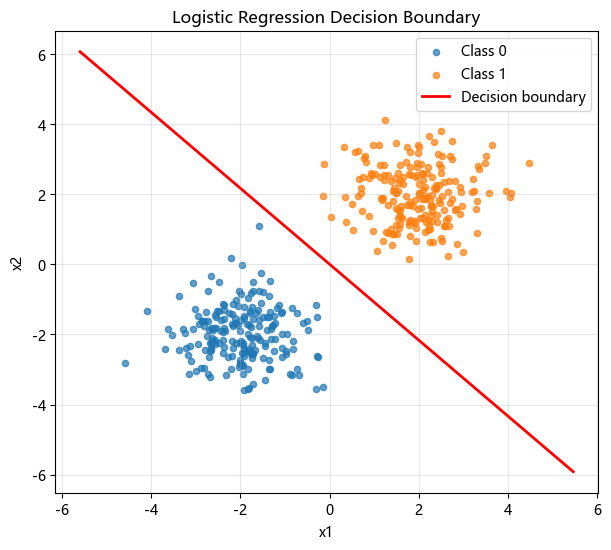


测试集准确率 = 1.0


In [17]:
# 6.2 编程题：不依赖深度学习框架高阶 API，实现二分类逻辑回归
# 任务：
# 1) 生成两类线性可分数据（每类 200 样本，特征 2 维）
# 2) 定义 sigmoid 和二元交叉熵
# 3) 梯度下降训练（lr=0.1, 迭代 1000）
# 4) 绘制决策边界，并在新测试集（100 样本）上计算准确率

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1) 生成线性可分数据
n_per_class = 200

# 类别 0：中心在 (-2, -2)
X0 = np.random.randn(n_per_class, 2) * 0.8 + np.array([-2, -2])
y0 = np.zeros((n_per_class, 1))

# 类别 1：中心在 (2, 2)
X1 = np.random.randn(n_per_class, 2) * 0.8 + np.array([2, 2])
y1 = np.ones((n_per_class, 1))

# 组合训练数据
X_train = np.vstack([X0, X1])
y_train = np.vstack([y0, y1])

# 打乱
perm = np.random.permutation(X_train.shape[0])
X_train = X_train[perm]
y_train = y_train[perm]

# 2) 定义 sigmoid 与二元交叉熵
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

# 参数初始化
W = np.zeros((2, 1))
b = 0.0

# 3) 梯度下降训练
lr = 0.1
iterations = 1000
n = X_train.shape[0]

for i in range(1, iterations + 1):
    # 前向传播
    logits = X_train @ W + b
    y_prob = sigmoid(logits)

    # 损失
    loss = binary_cross_entropy(y_train, y_prob)

    # 反向传播梯度
    dz = y_prob - y_train
    dW = (X_train.T @ dz) / n
    db = np.mean(dz)

    # 参数更新
    W -= lr * dW
    b -= lr * db

    if i % 200 == 0 or i == 1:
        print(f'Iter {i:4d}/{iterations}, loss = {loss:.6f}')

# 4) 可视化训练数据与决策边界
plt.figure(figsize=(7, 6))
plt.scatter(X_train[y_train[:, 0] == 0, 0], X_train[y_train[:, 0] == 0, 1], s=20, alpha=0.7, label='Class 0')
plt.scatter(X_train[y_train[:, 0] == 1, 0], X_train[y_train[:, 0] == 1, 1], s=20, alpha=0.7, label='Class 1')

# 决策边界：W0*x + W1*y + b = 0 -> y = -(W0*x+b)/W1
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
x_line = np.linspace(x_min, x_max, 200)
if abs(W[1, 0]) > 1e-12:
    y_line = -(W[0, 0] * x_line + b) / W[1, 0]
    plt.plot(x_line, y_line, 'r-', lw=2, label='Decision boundary')

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 生成新测试集（总计 100 个样本）
n_test_per_class = 50
X0_test = np.random.randn(n_test_per_class, 2) * 0.8 + np.array([-2, -2])
y0_test = np.zeros((n_test_per_class, 1))
X1_test = np.random.randn(n_test_per_class, 2) * 0.8 + np.array([2, 2])
y1_test = np.ones((n_test_per_class, 1))

X_test = np.vstack([X0_test, X1_test])
y_test = np.vstack([y0_test, y1_test])

# 测试准确率
y_test_prob = sigmoid(X_test @ W + b)
y_test_pred = (y_test_prob >= 0.5).astype(np.float64)
acc_test = np.mean(y_test_pred == y_test)

print('\n测试集准确率 =', acc_test)